--- STATISTICAL RELEVANCE ANALYSIS ---
Chi-Square Value: 254.96
P-Value: 9.0908e-11

RESULT: STATISTICALLY SIGNIFICANT!
The distribution of skeletal elements differs significantly between clusters.
This proves that the clusters represent distinct archaeological activities.


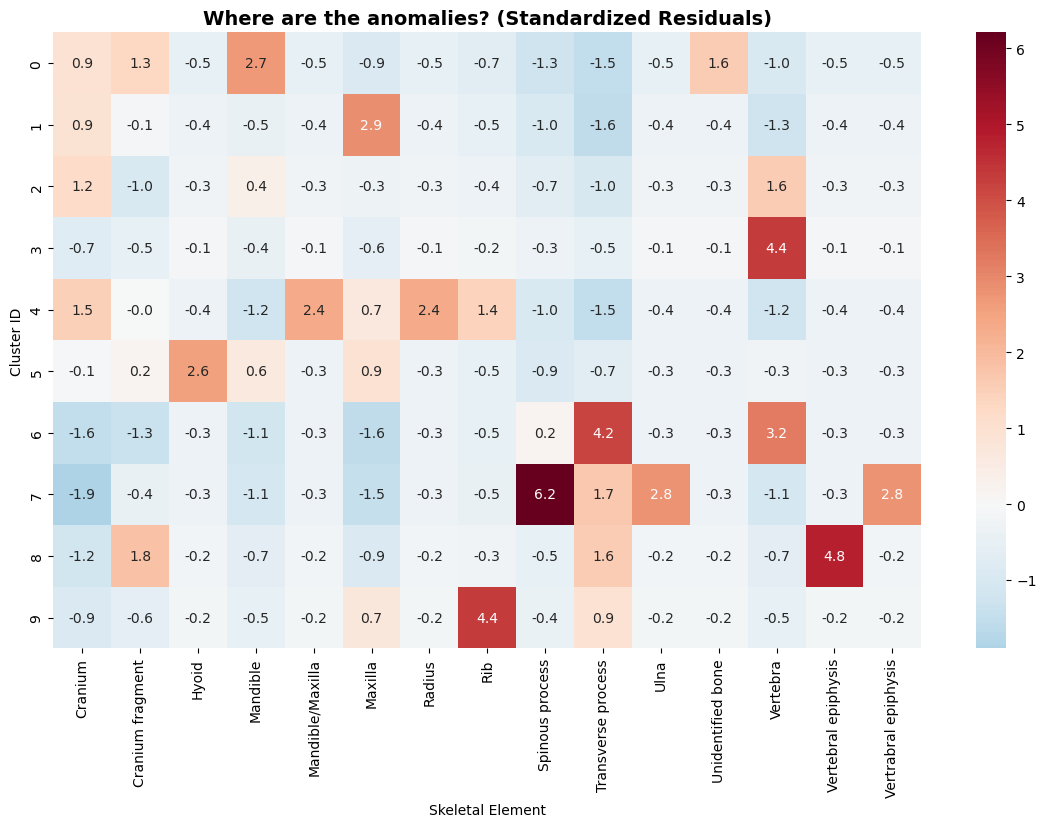


Residuals heatmap saved to: D:\Spitzbergen_2022\Sites\Gashamnda\GAS_stats\Whale_Cluster_Significance_Residuals.png


In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
from scipy.stats import chi2_contingency

# =================================================================
# 1. SETTINGS & PATHS
# =================================================================
base_path = r'D:\Spitzbergen_2022\Sites\Gashamnda\GAS_stats'
if not os.path.exists(base_path):
    base_path = os.getcwd()
input_name = 'Gashamna_Whale_Final_Analysis.gpkg'
points_path = os.path.join(base_path, input_name)

# =================================================================
# 2. LOAD & FILTER DATA
# =================================================================
whales = gpd.read_file(points_path, layer='Whale_Points_Clustered')

# Filter out Noise, Chunks, and Missing data
excluded_terms = ['Chunk', 'MISSING']
whales_clean = whales[
    (whales['cluster_id'] != -1) & 
    (~whales['element'].str.contains('|'.join(excluded_terms), case=False, na=False))
].copy()

# =================================================================
# 3. CREATE CONTINGENCY TABLE (Pivot Elements)
# =================================================================
pivot_elements = pd.crosstab(whales_clean['cluster_id'], whales_clean['element'])

# =================================================================
# 4. CHI-SQUARE TEST (Statistical Relevance)
# =================================================================
if pivot_elements.empty:
    print("Error: No data available for testing.")
else:
    # Perform the test
    chi2, p, dof, expected = chi2_contingency(pivot_elements)

    print("--- STATISTICAL RELEVANCE ANALYSIS ---")
    print(f"Chi-Square Value: {chi2:.2f}")
    print(f"P-Value: {p:.4e}")

    # Interpretation
    if p < 0.05:
        print("\nRESULT: STATISTICALLY SIGNIFICANT!")
        print("The distribution of skeletal elements differs significantly between clusters.")
        print("This proves that the clusters represent distinct archaeological activities.")
    else:
        print("\nRESULT: NOT SIGNIFICANT.")
        print("There is no strong evidence that the clusters have different anatomical profiles.")

    # =================================================================
    # 5. VISUALIZING RESIDUALS (Where is the relevance?)
    # =================================================================
    import numpy as np
    
    # Calculate row and column totals
    row_sums = pivot_elements.sum(axis=1).values[:, np.newaxis]
    col_sums = pivot_elements.sum(axis=0).values[np.newaxis, :]
    total_sum = pivot_elements.sum().sum()

    # Expected frequencies and proportions
    expected_freq = (row_sums @ col_sums) / total_sum
    row_prop = row_sums / total_sum
    col_prop = col_sums / total_sum

    # Adjusted Standardized Residuals (Haberman)
    variance = expected_freq * (1 - row_prop) * (1 - col_prop)
    adjusted_residuals = (pivot_elements - expected_freq) / np.sqrt(variance + 1e-9)

    plt.figure(figsize=(14, 8))
    sns.heatmap(adjusted_residuals, annot=True, cmap="RdBu_r", center=0, fmt='.1f')
    
    plt.title('Where are the anomalies? (Adjusted Standardized Residuals)', fontsize=14, fontweight='bold')
    plt.xlabel('Skeletal Element')
    plt.ylabel('Cluster ID')
    
    output_res = os.path.join(base_path, 'Whale_Cluster_Significance_Residuals.png')
    plt.savefig(output_res, dpi=300)
    plt.show()

    print(f"\nResiduals heatmap saved to: {output_res}")
